  Adding Rolling Std features...
  ✓ Total features: 14
  X shape: (2159950, 50, 14)
  y shape: (2159950,)
  Features: 14

Creating stratified split with 20 RUL bins...
  Bin  1 [0.00-0.05]: 108000 samples → Train:  86400, Test:  21600
  Bin  2 [0.05-0.10]: 108000 samples → Train:  86400, Test:  21600
  Bin  3 [0.10-0.15]: 108000 samples → Train:  86400, Test:  21600
  Bin  4 [0.15-0.20]: 108000 samples → Train:  86400, Test:  21600
  Bin  5 [0.20-0.25]: 108000 samples → Train:  86400, Test:  21600
  Bin  6 [0.25-0.30]: 108000 samples → Train:  86400, Test:  21600
  Bin  7 [0.30-0.35]: 108000 samples → Train:  86400, Test:  21600
  Bin  8 [0.35-0.40]: 108000 samples → Train:  86400, Test:  21600
  Bin  9 [0.40-0.45]: 108000 samples → Train:  86400, Test:  21600
  Bin 10 [0.45-0.50]: 108000 samples → Train:  86400, Test:  21600
  Bin 11 [0.50-0.55]: 108000 samples → Train:  86400, Test:  21600
  Bin 12 [0.55-0.60]: 108000 samples → Train:  86400, Test:  21600
  Bin 13 [0.60-0.65]: 10800

C:\Users\J\AppData\Local\Temp\ipykernel_4264\1878177742.py:519: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(stage_errors, labels=stage_labels)



✓ Stage analysis plots saved as 'performance_by_stage.png'


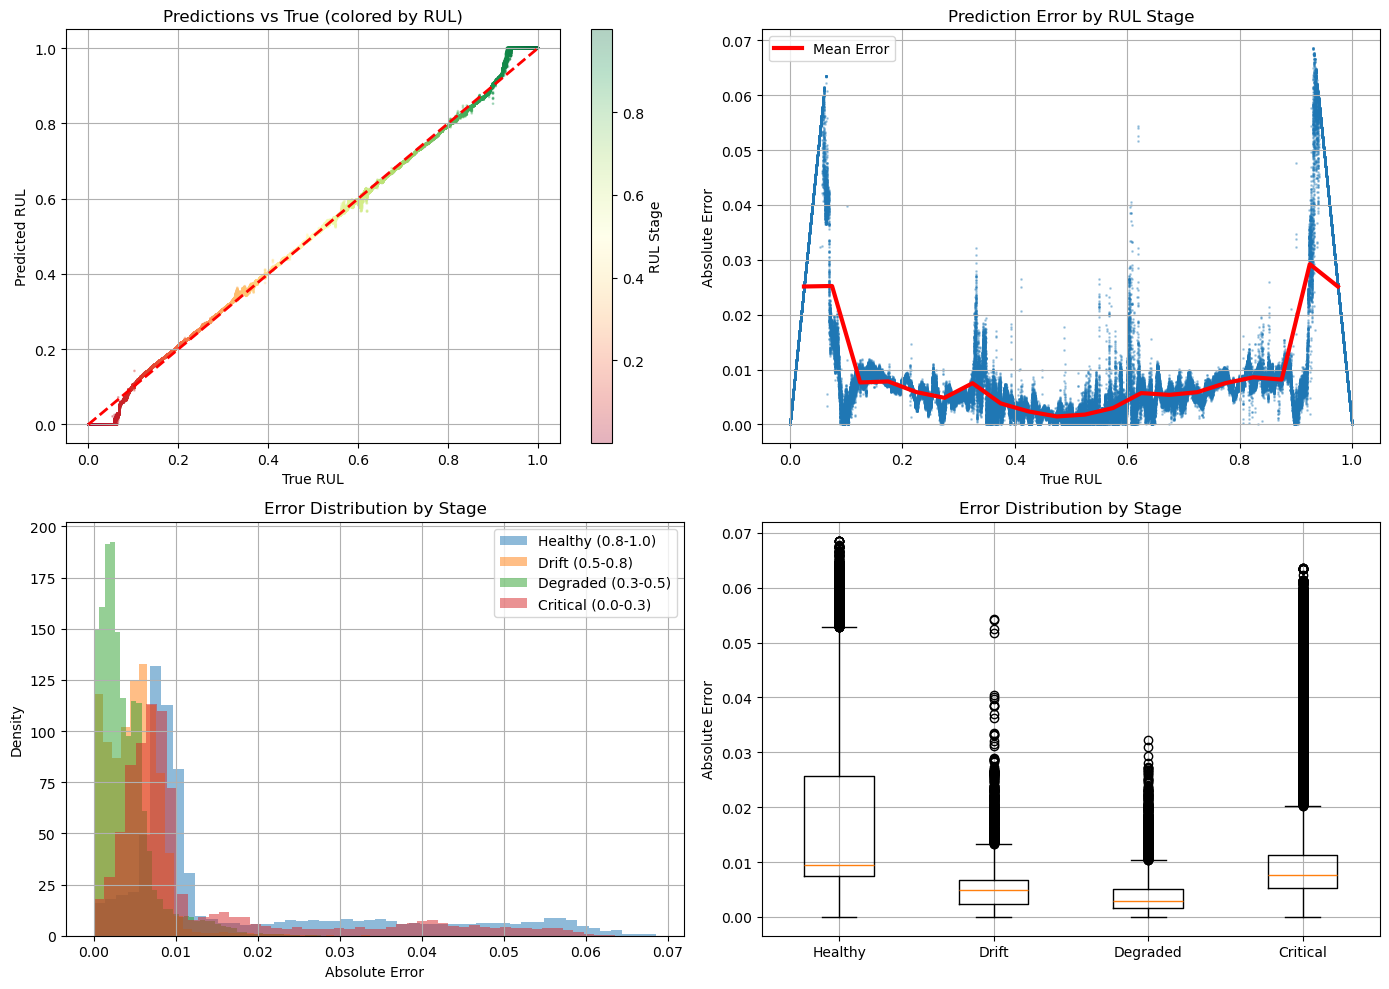

                              Summary

Overall Test Performance:
  R² Score: 0.997141
  MSE:      0.000238
  RMSE:     0.015434
  MAE:      0.009618
Stage-Specific Performance Check:
  ✓ All stages perform well!
    Best:  R²=0.9954
    Worst: R²=0.8214 (Healthy/Baseline (0.8-1.0))



In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from typing import Tuple, List
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import gc

class LSTM_data_prep:
    """
    Enhanced data preparation with features for ALL RUL stages.
    
    New Features:
    - Rolling Std: Captures variance (low=healthy, high=degraded)
    - Rate of Change: Detects early drift
    - CUSUM: Tracks cumulative drift 
    """
    
    def __init__(self, 
                 failure_sensors: List[str],
                 all_selected: List[str],
                 window_size: int = 50,
                 rolling_window: int = 5,
                 std_window: int = 20):
        self.failure_sensors = failure_sensors
        self.all_selected = all_selected
        self.window_size = window_size
        self.rolling_window = rolling_window
        self.std_window = std_window
        self.scaler = MinMaxScaler()
        self.feature_names = None
        
    def denoise(self, df: pd.DataFrame) -> pd.DataFrame:
        """Apply rolling mean denoising."""
        return (df[self.all_selected]
                .rolling(window=self.rolling_window, center=True)
                .mean()
                .bfill()
                .ffill())
    
    def add_advanced_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Add features that help at all RUL stages.
        
        Returns dataframe with:
        - 4 Original features 
        - 2 CUSUM features - good for drift/fault
        - 4 Rolling Std features - good for healthy stage
        - 4 Rate of Change features - good for early drift
        Total: 14 features
        """
        df_features = df.copy()
        
        # CUSUM 
        for col in self.failure_sensors:
            if col in df.columns:
                mean_val = df[col].mean()
                df_features[f'{col}_cusum'] = (df[col] - mean_val).cumsum()
        
        # Rolling Standard Deviation 
        # Healthy equipment has low variance, degraded has high variance
        print("  Adding Rolling Std features...")
        for col in self.all_selected:
            df_features[f'{col}_std'] = (
                df[col].rolling(window=self.std_window, min_periods=1)
                .std()
                .fillna(0)
            )
        
        # Rate of Change 
        for col in self.all_selected:
            df_features[f'{col}_roc'] = df[col].diff().fillna(0)
        
        print(f"  ✓ Total features: {len(df_features.columns)}")
        
        return df_features
    
    def scale_features(self, df: pd.DataFrame, fit: bool = True) -> np.ndarray:
        """Scale features to [0, 1] range."""
        if fit:
            return self.scaler.fit_transform(df)
        return self.scaler.transform(df)
    
    def create_sequences(self, data: np.ndarray) -> np.ndarray:
        """Create sliding window sequences."""
        X = []
        for i in range(self.window_size, len(data)):
            X.append(data[i-self.window_size:i, :])
        return np.array(X)
    
    def create_rul_target(self, df: pd.DataFrame) -> np.ndarray:
        """Create RUL target."""
        total_samples = len(df)
        rul_full = np.linspace(1.0, 0.0, total_samples)
        y = rul_full[self.window_size:]
        return y
    
    def prepare(self, df: pd.DataFrame, fit_scaler: bool = True) -> Tuple[np.ndarray, np.ndarray, List[str]]:
        """Complete preparation pipeline."""
        df_clean = self.denoise(df)
        df_features = self.add_advanced_features(df_clean)
        scaled_data = self.scale_features(df_features, fit=fit_scaler)
        X = self.create_sequences(scaled_data)
        y = self.create_rul_target(df_features)
        
        self.feature_names = df_features.columns.tolist()
        
        print(f"  X shape: {X.shape}")
        print(f"  y shape: {y.shape}")
        print(f"  Features: {len(self.feature_names)}")
        
        return X, y, self.feature_names

class RUL_LSTM(nn.Module):
    """
    Improved LSTM with more capacity to handle additional features.
    """
    
    def __init__(self, input_size, hidden_size=64, dropout=0.3):
        super(RUL_LSTM, self).__init__()
        
        # Two-layer LSTM
        self.lstm = nn.LSTM(
            input_size, 
            hidden_size, 
            batch_first=True, 
            num_layers=2,
            dropout=dropout
        )
        
        # Dense layers
        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        
        self.fc2 = nn.Linear(32, 1)
        
    def forward(self, x):
        # LSTM
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # Last time step
        
        # Dense
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        
        out = self.fc2(out)
        out = torch.clamp(out, 0.0, 1.0)  
        
        return out

def stratified_rul_split(X, y, test_size=0.2, n_bins=10, random_state=42):
    """
    Split data ensuring both train and test have samples from all RUL ranges.
    """
    np.random.seed(random_state)
    
    # Create RUL bins
    bins = np.linspace(0, 1, n_bins + 1)
    y_binned = np.digitize(y, bins)
    
    train_idx = []
    test_idx = []
    
    print(f"\nCreating stratified split with {n_bins} RUL bins...")
    
    # Sample from each bin
    for bin_num in range(1, n_bins + 1):
        bin_indices = np.where(y_binned == bin_num)[0]
        
        if len(bin_indices) == 0:
            continue
        
        # Shuffle within bin
        np.random.shuffle(bin_indices)
        
        n_test = int(len(bin_indices) * test_size)
        test_idx.extend(bin_indices[:n_test])
        train_idx.extend(bin_indices[n_test:])
        
        bin_min = bins[bin_num - 1]
        bin_max = bins[bin_num]
        print(f"  Bin {bin_num:2d} [{bin_min:.2f}-{bin_max:.2f}]: "
              f"{len(bin_indices):6d} samples → "
              f"Train: {len(bin_indices) - n_test:6d}, Test: {n_test:6d}")
    
    train_idx = np.array(train_idx)
    test_idx = np.array(test_idx)
    
    print(f"  Train: {len(train_idx):,} samples")
    print(f"  Test:  {len(test_idx):,} samples")
    
    return train_idx, test_idx

def split_into_cycles(df, cycle_length=50000):
    """
    If data contains multiple degradation cycles, split by cycles.
    Each cycle should start at high RUL and end at low RUL.
    """
    n_samples = len(df)
    n_cycles = n_samples // cycle_length
    
    print(f"\nDetected {n_cycles} potential degradation cycles")
    print(f"Cycle length: {cycle_length} samples")
    
    train_cycles = list(range(0, int(n_cycles * 0.8)))
    test_cycles = list(range(int(n_cycles * 0.8), n_cycles))
    
    train_idx = []
    test_idx = []
    
    for cycle in train_cycles:
        start = cycle * cycle_length
        end = min((cycle + 1) * cycle_length, n_samples)
        train_idx.extend(range(start, end))
    
    for cycle in test_cycles:
        start = cycle * cycle_length
        end = min((cycle + 1) * cycle_length, n_samples)
        test_idx.extend(range(start, end))
    
    return np.array(train_idx), np.array(test_idx)
    
class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def train_with_proper_split(model, X, y, train_idx, test_idx, device, 
                            num_epochs=100, batch_size=256):
    """Train with proper train/test split and return history including MSE."""
    
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]
    
    print(f"  Train: {len(X_train):,} samples, RUL range: [{y_train.min():.3f}, {y_train.max():.3f}]")
    print(f"  Test:  {len(X_test):,} samples, RUL range: [{y_test.min():.3f}, {y_test.max():.3f}]")
    
    train_dataset = RULDataset(X_train, y_train)
    test_dataset = RULDataset(X_test, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Optimizer with moderate regularization
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.05)  
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    
    best_val_loss = float('inf')
    patience_counter = 0
    patience = 15
    best_state = None
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_r2': [],
        'val_rmse': [],
        'val_mae': [],
        'val_mse': []
    }
   
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        
        model.eval()
        val_loss = 0
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()
                all_preds.append(outputs.cpu())
                all_targets.append(batch_y.cpu())
        
        val_loss /= len(test_loader)
        
        all_preds = torch.cat(all_preds).numpy()
        all_targets = torch.cat(all_targets).numpy()
        
        r2 = r2_score(all_targets, all_preds)
        mse = mean_squared_error(all_targets, all_preds)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(all_targets, all_preds)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_r2'].append(r2)
        history['val_mse'].append(mse)
        history['val_rmse'].append(rmse)
        history['val_mae'].append(mae)
        
        scheduler.step(val_loss)
        
        print(f"Epoch {epoch+1:3d} - Train: {train_loss:.6f} - Val: {val_loss:.6f} - "
              f"R²: {r2:7.4f} - MSE: {mse:.6f} - RMSE: {rmse:.4f} - MAE: {mae:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = model.state_dict().copy()
            print(f"  ✓ Best model")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n⚠ Early stopping")
                break
    
    if best_state is not None:
        model.load_state_dict(best_state)
        print("\n✓ Restored best model weights")
    
    return model, (all_targets, all_preds), history

def check_for_data_leakage(X, y, feature_names):
    """
    Check if any features are perfectly correlated with target.
    """
    print("data leakage detection")
    
    print("\nChecking for suspicious feature names:")
    suspicious_found = False
    for i, feat in enumerate(feature_names):
        if 'time' in feat.lower() or 'index' in feat.lower() or 'cycle' in feat.lower():
            print(f"  ⚠ Suspicious feature name: '{feat}'")
            suspicious_found = True
    
    if not suspicious_found:
        print("  ✓ No suspicious time/index/cycle features found")
    
    print("\nCorrelation with RUL target:")
    
    sample_size = min(10000, len(X))
    sample_indices = np.random.choice(len(X), sample_size, replace=False)
    
    # Get the last timestep of each sequence 
    X_last_timestep = X[sample_indices, -1, :]
    y_sampled = y[sample_indices]
    
    for feat_idx, feat_name in enumerate(feature_names):
        feature_vals = X_last_timestep[:, feat_idx]
        
        # Calculate correlation
        corr = np.corrcoef(feature_vals, y_sampled)[0, 1]
        
        if abs(corr) > 0.95:
            print(f"  ⚠ HIGH CORRELATION: {feat_name}: {corr:.4f} - POSSIBLE DATA LEAKAGE!")
        elif abs(corr) > 0.7:
            print(f"  {feat_name}: {corr:.4f} - Strong correlation")
        else:
            print(f"  ✓ {feat_name}: {corr:.4f}")

def verify_no_future_information(X, y, window_size=50):
    """Verify that X at time t doesn't contain information from time t+1 onwards."""

    print("future information check")
    
    # Check if the last value in sequence correlate too highly with target
    last_timestep_features = X[:, -1, :]  
    
    print("\nCorrelation of last timestep with immediate RUL:")
    for feat_idx in range(last_timestep_features.shape[1]):
        corr = np.corrcoef(last_timestep_features[:, feat_idx], y)[0, 1]
        if abs(corr) > 0.98:
            print(f"  ⚠ Feature {feat_idx}: {corr:.4f} - too high, possible future leak!")
        else:
            print(f"  ✓ Feature {feat_idx}: {corr:.4f}")

def analyze_by_condition(y_true, y_pred, rul_stages=None):
    """Analyze model performance at different RUL stages with MSE."""
  
    print("performance by RUL stage")
    
    if rul_stages is None:
        rul_stages = {
            'Healthy/Baseline (0.8-1.0)': (0.8, 1.0),
            'Early Drift (0.5-0.8)': (0.5, 0.8),
            'Moderate Degradation (0.3-0.5)': (0.3, 0.5),
            'Critical/Fault (0.0-0.3)': (0.0, 0.3)
        }
    
    results = {}
    
    for stage_name, (min_rul, max_rul) in rul_stages.items():
        mask = (y_true >= min_rul) & (y_true < max_rul)
        
        if mask.sum() == 0:
            print(f"\n{stage_name}: No samples")
            continue
        
        stage_true = y_true[mask]
        stage_pred = y_pred[mask]
        
        r2 = r2_score(stage_true, stage_pred)
        mse = mean_squared_error(stage_true, stage_pred)  
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(stage_true, stage_pred)
        
        results[stage_name] = {
            'n_samples': mask.sum(),
            'r2': r2,
            'mse': mse, 
            'rmse': rmse,
            'mae': mae
        }
        
        print(f"\n{stage_name}:")
        print(f"  Samples: {mask.sum():,}")
        print(f"  R²:   {r2:.4f}")
        print(f"  MSE:  {mse:.6f}")  
        print(f"  RMSE: {rmse:.4f}")
        print(f"  MAE:  {mae:.4f}")
        
        if r2 < 0.5:
            print(f"  ⚠ Poor performance in this stage!")
        elif r2 < 0.7:
            print(f"   Fair performance - could be improved")
        else:
            print(f"  ✓ Good performance")
    
    return results

def plot_performance_by_stage(y_true, y_pred):
    """Visualize predictions across different RUL ranges."""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Predictions vs True
    ax = axes[0, 0]
    scatter = ax.scatter(y_true, y_pred, c=y_true, cmap='RdYlGn', alpha=0.3, s=1)
    ax.plot([0, 1], [0, 1], 'r--', linewidth=2)
    ax.set_xlabel('True RUL')
    ax.set_ylabel('Predicted RUL')
    ax.set_title('Predictions vs True (colored by RUL)')
    ax.grid(True)
    plt.colorbar(scatter, ax=ax, label='RUL Stage')
    
    # Error by RUL value
    ax = axes[0, 1]
    errors = np.abs(y_true - y_pred)
    ax.scatter(y_true, errors, alpha=0.3, s=1)
    ax.set_xlabel('True RUL')
    ax.set_ylabel('Absolute Error')
    ax.set_title('Prediction Error by RUL Stage')
    ax.grid(True)
    
    # Binned average
    bins = np.linspace(0, 1, 21)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_errors = []
    for i in range(len(bins) - 1):
        mask = (y_true >= bins[i]) & (y_true < bins[i+1])
        if mask.sum() > 0:
            bin_errors.append(errors[mask].mean())
        else:
            bin_errors.append(0)
    ax.plot(bin_centers, bin_errors, 'r-', linewidth=3, label='Mean Error')
    ax.legend()
    
    # Histogram of errors by stage
    ax = axes[1, 0]
    stages = {
        'Healthy (0.8-1.0)': (0.8, 1.0),
        'Drift (0.5-0.8)': (0.5, 0.8),
        'Degraded (0.3-0.5)': (0.3, 0.5),
        'Critical (0.0-0.3)': (0.0, 0.3)
    }
    
    for stage_name, (min_rul, max_rul) in stages.items():
        mask = (y_true >= min_rul) & (y_true < max_rul)
        if mask.sum() > 0:
            stage_errors = errors[mask]
            ax.hist(stage_errors, bins=50, alpha=0.5, label=stage_name, density=True)
    
    ax.set_xlabel('Absolute Error')
    ax.set_ylabel('Density')
    ax.set_title('Error Distribution by Stage')
    ax.legend()
    ax.grid(True)
    
    # Box plot
    ax = axes[1, 1]
    stage_errors = []
    stage_labels = []
    
    for stage_name, (min_rul, max_rul) in stages.items():
        mask = (y_true >= min_rul) & (y_true < max_rul)
        if mask.sum() > 0:
            stage_errors.append(errors[mask])
            stage_labels.append(stage_name.split()[0])
    
    ax.boxplot(stage_errors, labels=stage_labels)
    ax.set_ylabel('Absolute Error')
    ax.set_title('Error Distribution by Stage')
    ax.grid(True)
    
    plt.tight_layout()
    plt.savefig('performance_by_stage.png', dpi=150, bbox_inches='tight')
    print("\n✓ Stage analysis plots saved as 'performance_by_stage.png'")
    plt.show()

def analyze_training_dynamics(history):
    """Analyze training dynamics."""

    print("training dynamic analysis")
    
    train_losses = history['train_loss']
    val_losses = history['val_loss']
    
    final_train = train_losses[-1]
    final_val = val_losses[-1]
    
    print(f"\nFinal Losses:")
    print(f"  Training: {final_train:.6f}")
    print(f"  Validation: {final_val:.6f}")
    print(f"  Ratio (Val/Train): {final_val/final_train:.3f}")
    
    if final_val < final_train:
        print("\n⚠ UNUSUAL: Validation loss < Training loss")
    else:
        print("\n✓ Normal pattern: Training loss < Validation loss")
        overfitting_ratio = final_val / final_train
        if overfitting_ratio > 2.0:
            print(f"  ⚠ High overfitting (ratio: {overfitting_ratio:.2f})")
        elif overfitting_ratio > 1.5:
            print(f"   Moderate overfitting (ratio: {overfitting_ratio:.2f})")
        else:
            print(f"  ✓ Healthy train/val gap (ratio: {overfitting_ratio:.2f})")

def plot_training_history(history):
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10)) 
    
    # Loss curves
    ax = axes[0, 0]
    ax.plot(history['train_loss'], label='Train Loss', linewidth=2)
    ax.plot(history['val_loss'], label='Val Loss', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE)')
    ax.set_title('Training and Validation Loss')
    ax.legend()
    ax.grid(True)
    ax.set_yscale('log')
    
    # R²
    ax = axes[0, 1]
    ax.plot(history['val_r2'], linewidth=2, color='green')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('R² Score')
    ax.set_title('Validation R²')
    ax.grid(True)
    ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='Excellent')
    ax.axhline(y=0.7, color='blue', linestyle='--', alpha=0.5, label='Good')
    ax.axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, label='Fair')
    ax.legend()
    
    # MSE
    ax = axes[0, 2]
    ax.plot(history['val_mse'], linewidth=2, color='orange')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.set_title('Validation MSE')
    ax.grid(True)
    
    # RMSE
    ax = axes[1, 0]
    ax.plot(history['val_rmse'], linewidth=2, color='red')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('RMSE')
    ax.set_title('Validation RMSE')
    ax.grid(True)
    
    # MAE
    ax = axes[1, 1]
    ax.plot(history['val_mae'], linewidth=2, color='purple')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MAE')
    ax.set_title('Validation MAE')
    ax.grid(True)
    
    ax = axes[1, 2]
    epochs = range(1, len(history['val_r2']) + 1)
    
    # Normalize metrics to [0, 1] for comparison
    ax.plot(epochs, history['val_r2'], label='R²', linewidth=2)
    
    # Invert and normalize error metrics 
    max_mse = max(history['val_mse'])
    normalized_mse = [1 - (x / max_mse) for x in history['val_mse']]
    ax.plot(epochs, normalized_mse, label='MSE (norm)', linewidth=2, alpha=0.7)
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Normalized Score')
    ax.set_title('All Metrics (Normalized)')
    ax.legend()
    ax.grid(True)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

def get_predictions_batched(model, X, device, batch_size=1024):
    """Get predictions in batches to avoid OOM."""
    model.eval()
    predictions = []
    
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            batch = X[i:i+batch_size]
            batch_tensor = torch.FloatTensor(batch).to(device)
            preds = model(batch_tensor).cpu().numpy()
            predictions.append(preds)
            
            del batch_tensor
            if device.type == 'cuda':
                torch.cuda.empty_cache()
    
    return np.concatenate(predictions).flatten()

def run_full_diagnostics(X, y, feature_names, model, train_idx, test_idx, 
                                   history, device, batch_size=1024):
    """Memory-efficient diagnostics."""
    print(" " * 15 + "model diagnostics")
    
    # Get predictions
    X_test = X[test_idx]
    y_test = y[test_idx]
    
    y_pred = get_predictions_batched(model, X_test, device, batch_size=batch_size)
    
    print(f"✓ Predictions complete: {len(y_pred):,} samples")
    
    # Performance by stage
    stage_results = analyze_by_condition(y_test, y_pred)
    
    if len(y_test) > 100000:
        print(f"\n⚠ Test set large, sampling 100k for plots...")
        sample_idx = np.random.choice(len(y_test), 100000, replace=False)
        plot_performance_by_stage(y_test[sample_idx], y_pred[sample_idx])
    else:
        plot_performance_by_stage(y_test, y_pred)
    
    print(" " * 30 + "Summary")
    
    overall_r2 = r2_score(y_test, y_pred)
    overall_mse = mean_squared_error(y_test, y_pred)
    overall_rmse = np.sqrt(overall_mse)
    overall_mae = mean_absolute_error(y_test, y_pred)
    
    print(f"\nOverall Test Performance:")
    print(f"  R² Score: {overall_r2:.6f}")
    print(f"  MSE:      {overall_mse:.6f}")
    print(f"  RMSE:     {overall_rmse:.6f}")
    print(f"  MAE:      {overall_mae:.6f}")
    
    # Stage-specific check
    print("Stage-Specific Performance Check:")
    
    worst_stage = None
    worst_r2 = 1.0
    best_r2 = -1.0
    
    for stage_name, metrics in stage_results.items():
        if metrics['r2'] < worst_r2:
            worst_r2 = metrics['r2']
            worst_stage = stage_name
        if metrics['r2'] > best_r2:
            best_r2 = metrics['r2']
    
    if worst_r2 < 0.5:
        print(f"  ⚠ CRITICAL: Worst stage '{worst_stage}' has R²={worst_r2:.4f}")
    elif worst_r2 < 0.7:
        print(f"  ⚡ WARNING: Worst stage '{worst_stage}' has R²={worst_r2:.4f}")
    else:
        print(f"  ✓ All stages perform well!")
        print(f"    Best:  R²={best_r2:.4f}")
        print(f"    Worst: R²={worst_r2:.4f} ({worst_stage})")
    
    print("\n" + "="*80)
    
    # Clean up
    del y_pred
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()

if __name__ == "__main__":
    
    failure_sensors = ['p2_juice_outlet', 'p1_juice_inlet_act2']
    all_selected = ['p2_juice_outlet', 'p1_juice_inlet_act2', 'vapour_temp', 'p1_water_inlet_act3']

    df = pd.read_csv('clean_data.txt', sep='\t')

    preparator = LSTM_data_prep(
        failure_sensors=failure_sensors,
        all_selected=all_selected,
        window_size=50,
        rolling_window=5,
        std_window=20
    )
    
    X, y, feature_names = preparator.prepare(df)
    
    train_idx, test_idx = stratified_rul_split(X, y, test_size=0.2, n_bins=20)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    n_features = X.shape[2]
    
    model = RUL_LSTM(input_size=n_features, hidden_size=64, dropout=0.3)
    model = model.to(device)
    
    print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    model, (y_true, y_pred), history = train_with_proper_split(
        model, X, y, train_idx, test_idx, device,
        num_epochs=100, batch_size=256
    )
    
    run_full_diagnostics(
        X=X,  
        y=y,   
        feature_names=feature_names,
        model=model,
        train_idx=train_idx,
        test_idx=test_idx,
        history=history,
        device=device,
        batch_size=1024
    )